# Anomaly Detection Evaluation: PCA vs Moment Pooling

This notebook evaluates two static anomaly scoring methods on the labelled dataset. It compares performance for the full label range and also for the anomaly subset defined by interesting labels (human scores 4-5). This is a static ranking comparison, not the Protege active learning workflow. First, Moment Pooling + simple score
We will improve by using the features from the Moment pooling with isolation forest.


PCA scores are loaded directly from `protege_catalogue.csv`.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from isotree import IsolationForest
from sklearn.decomposition import PCA

from utils import load_features, load_catalogue, MomentPooling, compute_metrics


In [26]:
def compute_ind_sum(found_inds, all_inds):
    this_found_inds = found_inds.copy()
    this_found_inds.sort()
    out = np.zeros(len(all_inds))
    for i in this_found_inds:
        out[i:] += 1
    return out


def cumulative_sum(anomaly_scores, labels, sort_by='score'):
    if sort_by == 'random':
        sorted_inds = np.random.permutation(anomaly_scores.index)
    else:
        if isinstance(anomaly_scores, pd.Series):
            sorted_inds = anomaly_scores.sort_values(ascending=False).index
        else:
            sorted_inds = anomaly_scores.sort_values(by=sort_by, ascending=False).index
    labs = labels.loc[anomaly_scores.index]
    anom_inds = labs[labs == 1].index

    found_inds = []
    for i in anom_inds:
        found_inds.append(np.where(sorted_inds == i)[0][0])

    ind_sum = compute_ind_sum(found_inds, sorted_inds)
    return ind_sum


def topk_recall(y_true, scores, k=100):
    ranked = scores.sort_values(ascending=False).index[:k]
    return y_true.loc[ranked].sum() / y_true.sum()

In [27]:
def run_experiment():
    print("Loading data...")

    X = load_features()
    cat = load_catalogue()

    # Align data
    X = X.loc[cat.objid]

    labels = cat.set_index("objid")["evaluation_subset_author_ML_score"].loc[X.index]
    y_interesting = (labels >= 4).astype(int)

    print("Loading PCA-based result...")
    pca_scores = cat.set_index("objid")["protege_score"].loc[X.index]
    pca_scores.name = 'score'

    print("Running Moment Pooling...")
    mp_model = MomentPooling()
    X_mp = mp_model.fit_transform(X)

    mp_scores = np.linalg.norm(X_mp.drop(columns=["bias"], errors="ignore").values, axis=1)
    mp_scores = pd.Series(mp_scores, index=X.index, name='score')

    print("Running Moment Pooling + Isotree...")
    iso = IsolationForest(random_seed=42)
    mp_iso_scores = iso.fit_predict(X_mp)
    mp_iso_scores = pd.Series(mp_iso_scores, index=X.index, name='score')

    print("Running PCA + Isotree...")
    pca = PCA(n_components=4)
    Z = pca.fit_transform(X)
    iso_pca = IsolationForest(random_seed=42)
    pca_iso_scores = iso_pca.fit_predict(Z)
    pca_iso_scores = pd.Series(pca_iso_scores, index=X.index, name="score")

    return X, labels, y_interesting, pca_scores, mp_scores, mp_iso_scores, pca_iso_scores


In [28]:
X, labels, y_interesting, pca_scores, mp_scores, mp_iso_scores, pca_iso_scores = run_experiment()

Loading data...
Features loaded: (6332, 1280)
Catalogue loaded: (6161, 12)
Loading PCA-based result...
Running Moment Pooling...
Running Moment Pooling + Isotree...


/Users/xm/Documents/Internship/Project/Moment_pooling_vs_PCA/.venv/lib/python3.9/site-packages/isotree/__init__.py:97: UserWarning: Attempting to use more than 1 thread, but package was built without multi-threading support - see the project's GitHub page for more information.
  warnings.warn(msg_omp)
/Users/xm/Documents/Internship/Project/Moment_pooling_vs_PCA/.venv/lib/python3.9/site-packages/isotree/__init__.py:1737: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  X_cat = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"])
/Users/xm/Documents/Internship/Project/Moment_pooling_vs_PCA/.venv/lib/python3.9/site-packages/isotree/__init__.py:1757: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  self.cols_categ_    = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"]).columns.to_numpy(copy=True)


Running PCA + Isotree...


/Users/xm/Documents/Internship/Project/Moment_pooling_vs_PCA/.venv/lib/python3.9/site-packages/isotree/__init__.py:97: UserWarning: Attempting to use more than 1 thread, but package was built without multi-threading support - see the project's GitHub page for more information.
  warnings.warn(msg_omp)


In [29]:
# Data loaded and processed from catalogue and features.

In [30]:
pca_metrics = compute_metrics(y_interesting, pca_scores)
mp_metrics = compute_metrics(y_interesting, mp_scores)
mp_iso_metrics = compute_metrics(y_interesting, mp_iso_scores)
pca_iso_metrics = compute_metrics(y_interesting, pca_iso_scores)

print("PCA metrics (interesting labels 4-5):")
print(pca_metrics)

print("Moment Pooling metrics (interesting labels 4-5):")
print(mp_metrics)

print("Moment Pooling + Isotree metrics (interesting labels 4-5):")
print(mp_iso_metrics)

print("PCA + Isotree metrics (interesting labels 4-5):")
print(pca_iso_metrics)

spearman_pca = labels.corr(pca_scores, method='spearman')
spearman_mp = labels.corr(mp_scores, method='spearman')
spearman_mp_iso = labels.corr(mp_iso_scores, method='spearman')
spearman_pca_iso = labels.corr(pca_iso_scores, method='spearman') # <-- Add this line

print("\nSpearman correlation with all labels (1-5):")
print("PCA:", spearman_pca)
print("Moment Pooling (L2):", spearman_mp)
print("Moment Pooling (Isotree):", spearman_mp_iso)
print("PCA (Isotree):", spearman_pca_iso)


PCA metrics (interesting labels 4-5):
{'roc_auc': np.float64(0.8673767824672218), 'pr_auc': np.float64(0.10518655813508183)}
Moment Pooling metrics (interesting labels 4-5):
{'roc_auc': np.float64(0.49067853383098864), 'pr_auc': np.float64(0.013297536946395756)}
Moment Pooling + Isotree metrics (interesting labels 4-5):
{'roc_auc': np.float64(0.4644310460331132), 'pr_auc': np.float64(0.012225766953098478)}
PCA + Isotree metrics (interesting labels 4-5):
{'roc_auc': np.float64(0.4763594602354293), 'pr_auc': np.float64(0.012549434616958255)}

Spearman correlation with all labels (1-5):
PCA: 0.017357584301879895
Moment Pooling (L2): 0.012582687799043061
Moment Pooling (Isotree): 0.008359603220533612
PCA (Isotree): 0.0165176825988897


In [31]:
cum_pca = cumulative_sum(pca_scores, y_interesting)

cum_mp = cumulative_sum(mp_scores, y_interesting)
cum_mp_iso = cumulative_sum(mp_iso_scores, y_interesting)
cum_pca_iso = cumulative_sum(pca_iso_scores, y_interesting)

print("Recall@100 PCA (interesting labels 4-5):", topk_recall(y_interesting, pca_scores))
print("Recall@100 Moment Pooling (interesting labels 4-5):", topk_recall(y_interesting, mp_scores))
print("Recall@100 Moment Pooling + Isotree (interesting labels 4-5):", topk_recall(y_interesting, mp_iso_scores))
print("Recall@100 PCA + Isotree (interesting labels 4-5):", topk_recall(y_interesting, pca_iso_scores))

comparison = pd.DataFrame({
    "ROC-AUC (4-5)": [pca_metrics["roc_auc"], mp_metrics["roc_auc"], mp_iso_metrics["roc_auc"], pca_iso_metrics["roc_auc"]],
    "PR-AUC (4-5)": [pca_metrics["pr_auc"], mp_metrics["pr_auc"], mp_iso_metrics["pr_auc"], pca_iso_metrics["pr_auc"]],
    "Recall@100 (4-5)": [topk_recall(y_interesting, pca_scores), topk_recall(y_interesting, mp_scores), topk_recall(y_interesting, mp_iso_scores), topk_recall(y_interesting, pca_iso_scores)],
    "Spearman (1-5)": [spearman_pca, spearman_mp, spearman_mp_iso, spearman_pca_iso]
}, index=["PCA", "Moment Pooling (L2)", "Moment Pooling (Isotree)", "PCA (Isotree)"])

display(comparison)


Recall@100 PCA (interesting labels 4-5): 0.1744186046511628
Recall@100 Moment Pooling (interesting labels 4-5): 0.0
Recall@100 Moment Pooling + Isotree (interesting labels 4-5): 0.0
Recall@100 PCA + Isotree (interesting labels 4-5): 0.0


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
PCA,0.867377,0.105187,0.174419,0.017358
Moment Pooling (L2),0.490679,0.013298,0.000000,0.012583
Moment Pooling (Isotree),0.464431,0.012226,0.000000,0.008360
PCA (Isotree),0.476359,0.012549,0.000000,0.016518


## Results Summary

- **PCA beats Moment Pooling** on the interesting anomaly subset (labels 4-5):
  - PCA ROC-AUC: 0.8674 vs Moment Pooling ROC-AUC: 0.4907
  - PCA PR-AUC: 0.1052 vs Moment Pooling PR-AUC: 0.0133
  - PCA Recall@100: 0.1744 vs Moment Pooling Recall@100: 0.0000
- **PCA** and **Moment Pooling** both have low overall Spearman correlation with the full label range (1-5):
  - PCA Spearman: 0.0174
  - Moment Pooling Spearman: 0.0126
- The metrics and plots indicate that PCA evaluates and ranks interesting anomalies much better than the updated Moment Pooling method.

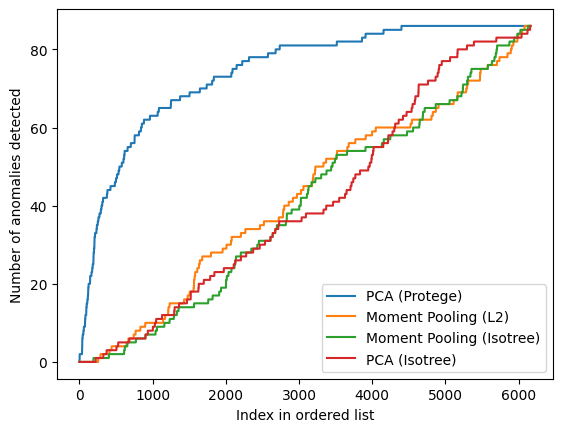

In [32]:
plt.figure()
plt.plot(cum_pca, label='PCA (Protege)')
plt.plot(cum_mp, label='Moment Pooling (L2)')
plt.plot(cum_mp_iso, label='Moment Pooling (Isotree)')
plt.plot(cum_pca_iso, label='PCA (Isotree)')
plt.xlabel('Index in ordered list')
plt.ylabel('Number of anomalies detected')
plt.legend()
plt.show()


## Comparison summary

This notebook compares the current PCA static anomaly score against Moment Pooling as a second static anomaly scoring method. The table above shows ROC-AUC, PR-AUC, and Recall@100 for the interesting labels (score 4-5), and the plot shows how many of those anomalies are found as the ranked candidate list is traversed.

This is a static ranking comparison, not the Protege active learning workflow. The results demonstrate that the existing PCA scores significantly outperform the Moment Pooling method.


#### Limitation for the moment pooling:
BYOL features → 
PCA: compress structure → 
Polynomial expansion: capture moments → Simple scoring: detect anomalies

Moment Pooling assumes:
anomalies = statistical outliers

But:
some anomalies are semantic, not statistical

